# License

In [ ]:
# Copyright (C) 2026 Matthew Jones and Andrea Rajšić
#
# This program is free software: you can redistribute it and/or modify
# it under the terms of the GNU General Public License as published by
# the Free Software Foundation, either version 3 of the License, or
# (at your option) any later version.
#
# This program is distributed in the hope that it will be useful,
# but WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
# GNU General Public License for more details.
#
# You should have received a copy of the GNU General Public License
# along with this program.  If not, see <https://www.gnu.org/licenses/>.

# Script setup

In [1]:
### Generic imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import geopandas as gpd
import warnings, pickle

from matplotlib import patheffects
from shapely.geometry import Polygon
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm

import sys
from pathlib import Path


In [2]:
### Define working directory
WORKDIR = Path.cwd().resolve()
if (WORKDIR / 'src' / 'regolith_map').exists():
  REPO_ROOT = WORKDIR
elif (WORKDIR.parent / 'src' / 'regolith_map').exists():
  REPO_ROOT = WORKDIR.parent
else:
  raise FileNotFoundError("Could not locate repository root containing src/regolith_map")

SRC_DIR = REPO_ROOT / 'src'
REPRODUCE_DIR = REPO_ROOT / 'reproduce'
DATA_DIR = REPRODUCE_DIR / 'data'

if str(SRC_DIR) not in sys.path:
  sys.path.insert(0, str(SRC_DIR))
  

In [3]:
### Import mapping and processing utilities
from regolith_map.projections import GLOBE, PLATE_CARREE, LAEA_NS, LAEA_FS
from regolith_map.helpers import parse_measurements, generate_limb_circle, generate_gridpoints, generate_nearside_mask
from regolith_map.interp import build_tree, interpolate_at_points, spherical_centroid
from regolith_map.plotting import generate_projected_axes
from regolith_map.estimation import logistic_crossover_estimate


## Define paths

In [4]:
### Define and check file paths
# Maria geometry
maria_file_speyerer = DATA_DIR / "LROC_GLOBAL_MARE_180/LROC_GLOBAL_MARE_180.SHP"
maria_file_usgs = DATA_DIR / "USGSmare.pkl"
# All df_craters (this work)
craters_path = DATA_DIR / 'Rajsic-etal_2026_Table_SM1-SM2.xlsx'
# All regolith estimates (this work and others)
regolith_path = DATA_DIR / 'RegolithData_Literature.xlsx'
# Map datasets
wac_file = DATA_DIR / 'map_wac.pkl'
# Cached variables
permutation_cache = REPRODUCE_DIR / 'cache/permutations_10k.pkl'
bootstraps_mare_cache = REPRODUCE_DIR / 'cache/bootstraps_mare_1k.pkl'
bootstraps_highlands_cache = REPRODUCE_DIR / 'cache/bootstraps_highlands_1k.pkl'
rarefaction_mare_cache = REPRODUCE_DIR / 'cache/rarefaction_mare_200x1.pkl'
rarefaction_highlands_cache = REPRODUCE_DIR / 'cache/rarefaction_highlands_200x1.pkl'

for path in [
  maria_file_speyerer,
  maria_file_usgs,
  craters_path,
  regolith_path,
  wac_file,
]:
  if not path.exists():
    raise FileNotFoundError(f"Missing file: {path}. Place it in reproduce/data.")


# User input

In [5]:
### Paths
OUTPUT_PATH = REPRODUCE_DIR / 'outputs'
SAVEFIG_ALL = True

### Macros
USE_USGS_MARIA = False

In [6]:
### Automated things
if not OUTPUT_PATH.exists():
  OUTPUT_PATH.mkdir(parents=True, exist_ok=True)


# Import and format data

In [7]:
### Define maria geometry
if USE_USGS_MARIA:
  with open(maria_file_usgs, 'rb') as ff:
    mare = pickle.load(ff)
else:
  mare = gpd.read_file(maria_file_speyerer)
  mare['geometry'] = mare.geometry.make_valid()

mask_ns = gpd.GeoDataFrame(geometry=[Polygon(generate_limb_circle().vertices)], crs=PLATE_CARREE).to_crs(mare.crs)
mare_ns = mare.overlay(mask_ns, how='intersection').to_crs(LAEA_NS)
mare_fs = mare.overlay(mask_ns, how='difference').to_crs(LAEA_FS)

### Merge all mare units to eliminate internal mare unit–border lines
mare_dissolved = gpd.GeoDataFrame(
  {'name': ['all']},
  geometry = [mare.union_all()],
  crs = mare.crs
)
mare_ns_dissolved = gpd.GeoDataFrame(
  {'name': ['all nearside']},
  geometry = [mare_ns.union_all()],
  crs = mare_ns.crs
)
mare_fs_dissolved = gpd.GeoDataFrame(
  {'name': ['all farside']},
  geometry = [mare_fs.union_all()],
  crs = mare_fs.crs
)


/usr/local/Caskroom/miniforge/base/envs/lunar-surface-regolith/lib/python3.10/site-packages/geopandas/tools/overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 1 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)
/usr/local/Caskroom/miniforge/base/envs/lunar-surface-regolith/lib/python3.10/site-packages/geopandas/tools/overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 1 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


In [8]:
### WAC data
with open(DATA_DIR / wac_file, 'rb') as ff:
  wac_lon, wac_lat, wac_vals = pickle.load(ff)

In [9]:
### Read in all individual df_craters (this work)
df_craters = pd.read_excel(craters_path)
df_craters['exc_depth'] = df_craters['diameter'] * 0.084
df_craters


,lat,lon,diameter,lithology,is_REC,age_Ga,group,exc_depth
0,27.188300,-71.314680,20.34,mare,False,NaN,NaN,1.70856
1,11.324460,-40.683520,20.36,mare,False,NaN,NaN,1.71024
2,11.492210,-40.623950,22.58,mare,False,NaN,NaN,1.89672
3,10.902780,-40.624280,22.62,mare,False,NaN,NaN,1.90008
4,27.251880,-71.012300,23.24,mare,False,NaN,NaN,1.95216
...,...,...,...,...,...,...,...,...
342,23.321776,-107.165745,190.00,highlands,True,NaN,NaN,15.96000
343,24.978518,-107.802299,94.70,highlands,True,NaN,NaN,7.95480
344,24.768933,-107.668836,110.00,highlands,True,NaN,NaN,9.24000
345,23.518183,-107.516129,190.00,highlands,True,NaN,NaN,15.96000


In [10]:
### Read in regolith estimates from other work
df_regolith = pd.read_excel(regolith_path)
df_regolith

,lat,lon,regolith_thickness (m),Source,Method
0,34.733275,-14.923168,6.50,Yu+2025;Yan+2025;Zhang+2025,Change'3: Lunar Penetrating Radar
1,-44.400000,176.200000,12.50,Yu+2025;Yan+2025;Zhang+2025,Change'4: Lunar Penetrating Radar
2,40.763881,-58.385738,5.00,Yu+2025;Yan+2025;Zhang+2025,Change'5: Lunar Regolith Penetrating Radar
3,-37.063191,-153.720000,6.00,Yu+2025;Yan+2025;Zhang+2025,"Change'6: in situ data from imagery, spectral ..."
4,0.680746,23.466554,4.40,Apollo 11,Passive seismic
5,-2.993013,-23.415304,3.70,Apollo 12,Passive seismic
6,-4.632809,-17.485191,8.50,Apollo 14,Active seismic
7,26.073404,3.660000,4.40,Apollo 15,Passive seismic
8,-9.006596,15.470000,12.20,Apollo 16,Active seismic
9,20.207510,30.666692,4.00,Apollo 17,Active seismic


# Plot settings

In [11]:
### Set matplotlib rcParams
plt.style.use(REPRODUCE_DIR / 'regolith_map.mplstyle')

### Projected axes
# Positional args
arg_hemispheres = [
  [LAEA_NS, LAEA_FS]
]
# Keywords
kw_hemispheres = {
  'nrow': 1,
  'ncol': 2,
  'ax_titles': ['Nearside', 'Farside'],
  'map_height': 3,
  'boundaries': generate_limb_circle(),
  'with_cax': True,
  'cax_orientation': 'horizontal',
  'kw_gspec': {
    'wspace': .05,
    'hspace': .05,
  },
}

### Estimated thickness
# Keywords
kw_regolith = {
  'vmin': 2,
  'vmax': 10,
  'shading': 'flat',
  'transform': PLATE_CARREE,
  'zorder': 0,
}

# ### Measured thickness
# # Positional args
# arg_scatter = [
#   df_regolith['lon'],
#   df_regolith['lat']
# ]
# # Keywords
# kw_scatter = {
#   's': 5,
#   'c': df_regolith['regolith_thickness (m)'],
#   'vmin': kw_regolith.get('vmin'),
#   'vmax': kw_regolith.get('vmax'),
#   'linewidths': .5,
#   'edgecolors': [1, 1, 1, 1],
#   'transform': PLATE_CARREE,
#   'zorder': 100,
# }
# # Define and add dropshadow effect
# shadow_offset = kw_scatter.get('linewidths', 0) * 0.8
# line_shadow = [
#   patheffects.SimpleLineShadow(
#     offset = (shadow_offset, -shadow_offset), 
#     alpha = .5
#   ),
#   patheffects.Normal()
# ]
# kw_scatter.update({'path_effects': line_shadow})

### Maria patches
# Keywords
kw_mare = {
  'linewidth': .3,
  'edgecolor': [1, 1, 1, 0],
  'facecolor': [.8, .8, .8, .6],
  'zorder': 1,
}

### Colorbar
# Keywords
kw_cbar = {
  'orientation': kw_hemispheres.get('cax_orientation'),
  'label': 'Regolith thickness (m)',
}

### Gridlines
# Keywords
loc = mpl.ticker.MultipleLocator(30)
kw_gridlines = {
  'crs': PLATE_CARREE,
  'xlocs': loc,
  'ylocs': loc,
  'linewidth': kw_mare.get('linewidth', .3),
  'alpha': .8,
  # 'zorder': 10, #doesn't work -- stuck at around 2.5, supposedly
}

### WAC settings
# Positional args
arg_wac = [
  wac_lon,
  wac_lat
]
# Keywords
kw_wac = {
  'cmap': 'grey',
  'vmin': 0,
  'vmax': 255,
  # 'shading': 'flat',
  'transform': PLATE_CARREE,
  'zorder': 0,
}

### Point settings (this work)
# Keywords
kw_thiswork = {
  's': 5,
  'color': (1, .5, 0),
  'linewidths': .5,
  'edgecolors': [1, 1, 1, 1],
  'transform': PLATE_CARREE,
  'zorder': 100,
}
# Define and add dropshadow effect
shadow_offset_thiswork = kw_thiswork.get('linewidths', 0) * 0.8
line_shadow_thiswork = [
  patheffects.SimpleLineShadow(
    offset = (shadow_offset_thiswork, -shadow_offset_thiswork), 
    alpha = .5
  ),
  patheffects.Normal()
]
kw_thiswork.update({'path_effects': line_shadow_thiswork})


# Plot this study's measurement points

## Cluster analysis (to assign crater groups and find regolith estimate coordinates)

In [12]:
### User settings
MIN_CRATERS_PER_GROUP = 3


In [13]:
### Clustering workflow adapted from Gemini
### Define clustering coordinates
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
R0 = 1737 #km -- lunar radius & distance-per-radian
lat_rad = np.radians(df_craters['lat'])
lon_rad = np.radians(df_craters['lon'])
x = R0 * np.cos(lat_rad) * np.cos(lon_rad)
y = R0 * np.cos(lat_rad) * np.sin(lon_rad)
z = R0 * np.sin(lat_rad)
coords_3d = np.column_stack([x, y, z])
# Normalize the coordinates
scaler = MinMaxScaler()
coords_normalized = scaler.fit_transform(coords_3d)
# One-hot encode the lithology
onehot = OneHotEncoder(drop='first').fit_transform(df_craters[['lithology']])
# print(onehot)
# Compose the data
XX = np.column_stack([coords_normalized, onehot.toarray()])

### Set up DBSCAN
from sklearn.cluster import DBSCAN
search_distance = 150 #km
epsilon = search_distance / R0
### Run DBSCAN
db = DBSCAN(eps=epsilon, min_samples=1)
db.fit(XX)
df_craters['group'] = db.labels_ + 1
groups, counts = np.unique(df_craters['group'], return_counts=True)
print("groups:", groups)
print("counts:", counts)


groups: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
counts: [28 19 23 10 34 34 37 23 34 34 13 12 45  1]


In [14]:
### Remove groups with too few craters
keep_groups = groups[counts >= MIN_CRATERS_PER_GROUP]
df_craters = df_craters[df_craters['group'].isin(keep_groups)].copy()
df_craters.reset_index(drop=True, inplace=True)

# Refresh group metadata after filtering
groups, counts = np.unique(df_craters['group'], return_counts=True)
print("groups:", groups)
print("counts:", counts)
df_craters

groups: [ 1  2  3  4  5  6  7  8  9 10 11 12 13]
counts: [28 19 23 10 34 34 37 23 34 34 13 12 45]


,lat,lon,diameter,lithology,is_REC,age_Ga,group,exc_depth
0,27.188300,-71.314680,20.34,mare,False,NaN,1,1.70856
1,11.324460,-40.683520,20.36,mare,False,NaN,2,1.71024
2,11.492210,-40.623950,22.58,mare,False,NaN,2,1.89672
3,10.902780,-40.624280,22.62,mare,False,NaN,2,1.90008
4,27.251880,-71.012300,23.24,mare,False,NaN,1,1.95216
...,...,...,...,...,...,...,...,...
341,23.321776,-107.165745,190.00,highlands,True,NaN,10,15.96000
342,24.978518,-107.802299,94.70,highlands,True,NaN,10,7.95480
343,24.768933,-107.668836,110.00,highlands,True,NaN,10,9.24000
344,23.518183,-107.516129,190.00,highlands,True,NaN,10,15.96000


In [15]:
### Retrieve cluster centroids
centroids = {}
for group in groups:
  centroids[group] = spherical_centroid(
    df_craters.loc[df_craters['group'] == group, 'lat'],
    df_craters.loc[df_craters['group'] == group, 'lon']
  )
centroid_coords = np.asarray(list(centroids.values())).T
print("group    lat     lon ")
for group, centroid in centroids.items():
  print(f"  {group:>2d}: ({centroid[0]:>6.2f}, {centroid[1]:>7.2f})")


group    lat     lon 
   1: ( 27.11,  -71.21)
   2: ( 11.24,  -40.68)
   3: ( 18.44,  -58.09)
   4: ( 13.42,  -54.88)
   5: ( 17.94,  -76.06)
   6: ( 41.35,  -55.38)
   7: ( 42.57,  -99.03)
   8: ( 23.14, -149.71)
   9: ( -7.53, -134.09)
  10: ( 23.38, -108.01)
  11: ( 16.58,  -76.05)
  12: ( 28.56, -135.76)
  13: ( 10.36, -139.74)


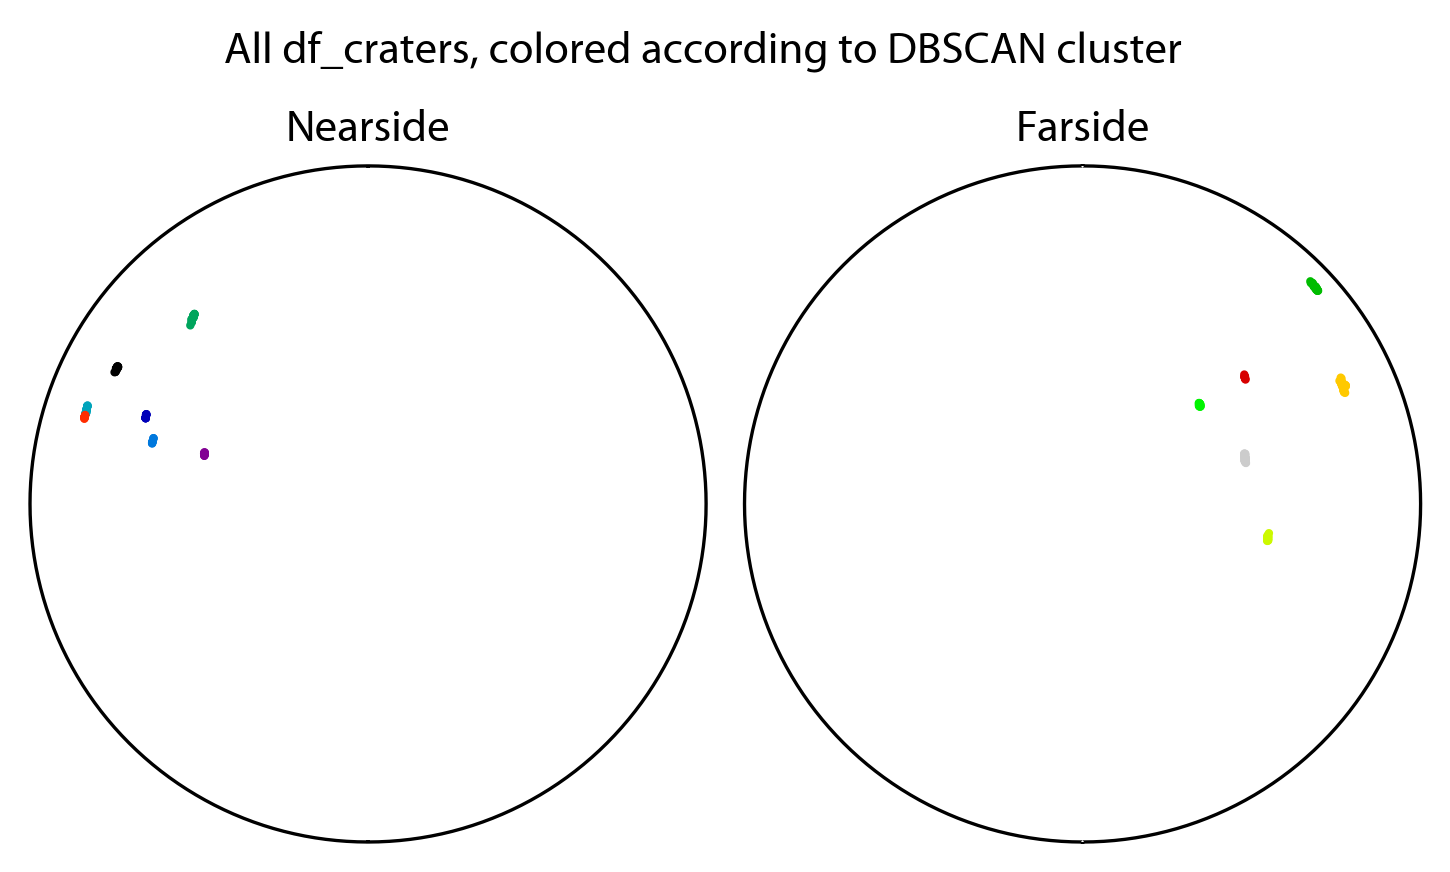

In [16]:
### Plot clusters to verify
# Initialize axes
with warnings.catch_warnings():
  warnings.simplefilter("ignore")
  # Set up axes
  fig, ax, cax = generate_projected_axes(*arg_hemispheres, **kw_hemispheres)
  ax[0].set_title('Nearside')
  ax[1].set_title('Farside')
  cax.remove()
  # Plot df_craters colored according to cluster
  for a in ax:
    a.scatter(
      df_craters['lon'], df_craters['lat'], 
      c = df_craters['group'], cmap = 'nipy_spectral',
      s = 1, alpha=1, 
      transform = PLATE_CARREE
    )
  fig.suptitle("All df_craters, colored according to DBSCAN cluster", y=1.02)
  plt.show()


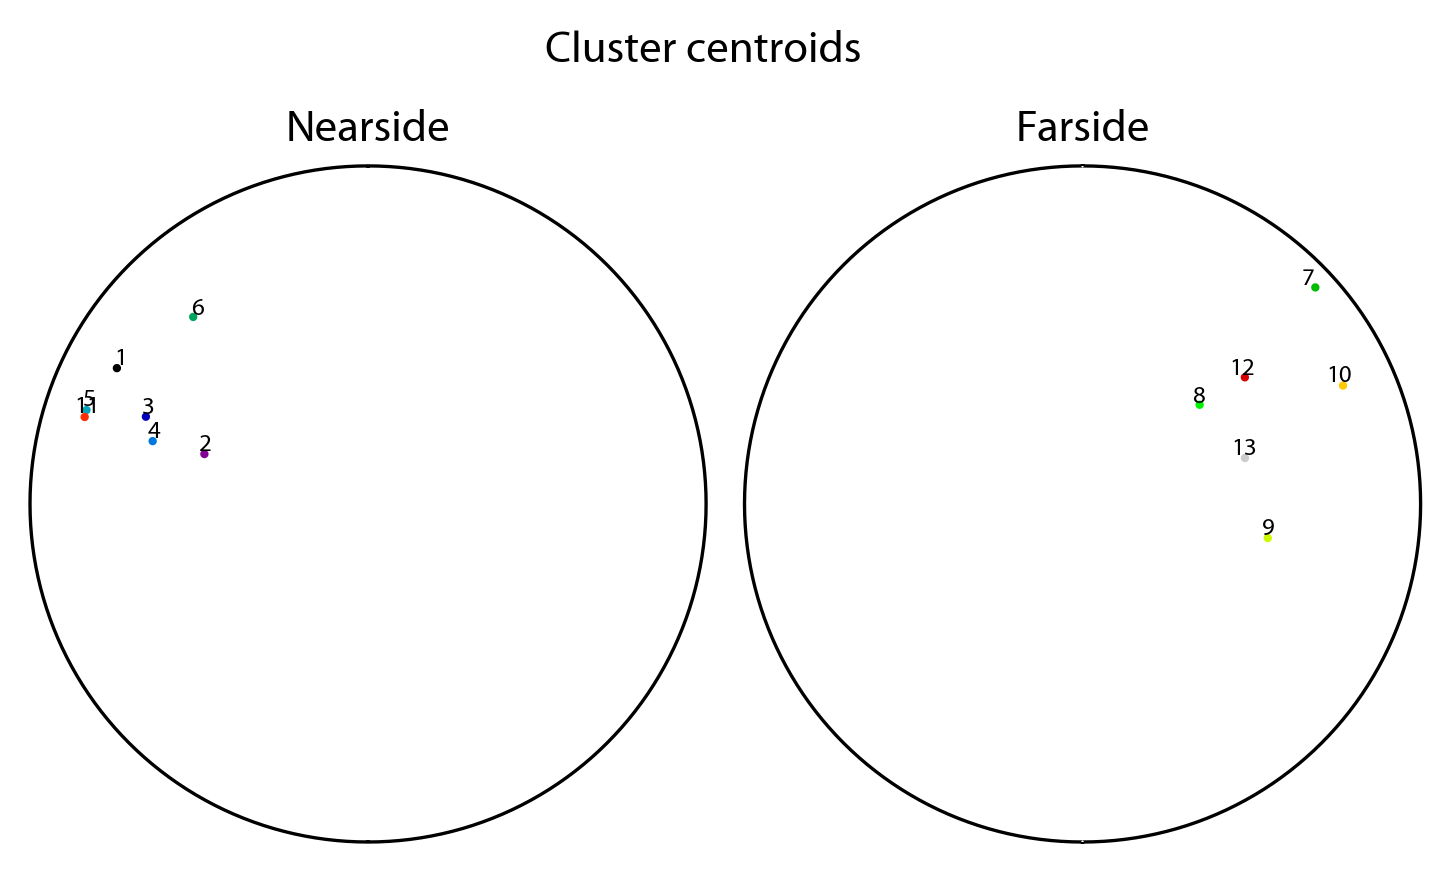

In [17]:
### Plot centroids to verify
# Initialize axes
with warnings.catch_warnings():
  warnings.simplefilter("ignore")
  # Set up axes
  fig, ax, cax = generate_projected_axes(*arg_hemispheres, **kw_hemispheres)
  ax[0].set_title('Nearside')
  ax[1].set_title('Farside')
  cax.remove()
  # Plot df_craters colored according to cluster
  for a in ax:
    a.scatter(
      centroid_coords[1], centroid_coords[0], 
      c = groups, cmap = 'nipy_spectral',
      s = 1, alpha=1, 
      transform = PLATE_CARREE
    )
  for g in groups:
    centroid_lat = centroids[g][0]
    centroid_lon = centroids[g][1]
    if (centroid_lon >= -90) and (centroid_lon < 90):
      label_ax = 0
    else:
      label_ax = 1
    ax[label_ax].text(
      centroid_lon, centroid_lat+2, str(g), 
      transform = PLATE_CARREE,
      fontsize = 6,
      ha = 'center',
      va = 'center',
      zorder = 200
    )
  fig.suptitle("Cluster centroids", y=1.02)
  plt.show()


## Plot the figure

In [18]:
### User settings
SAVEFIG_THISWORKLOCATION = False
SHOWMARE_THISWORKLOCATION = True


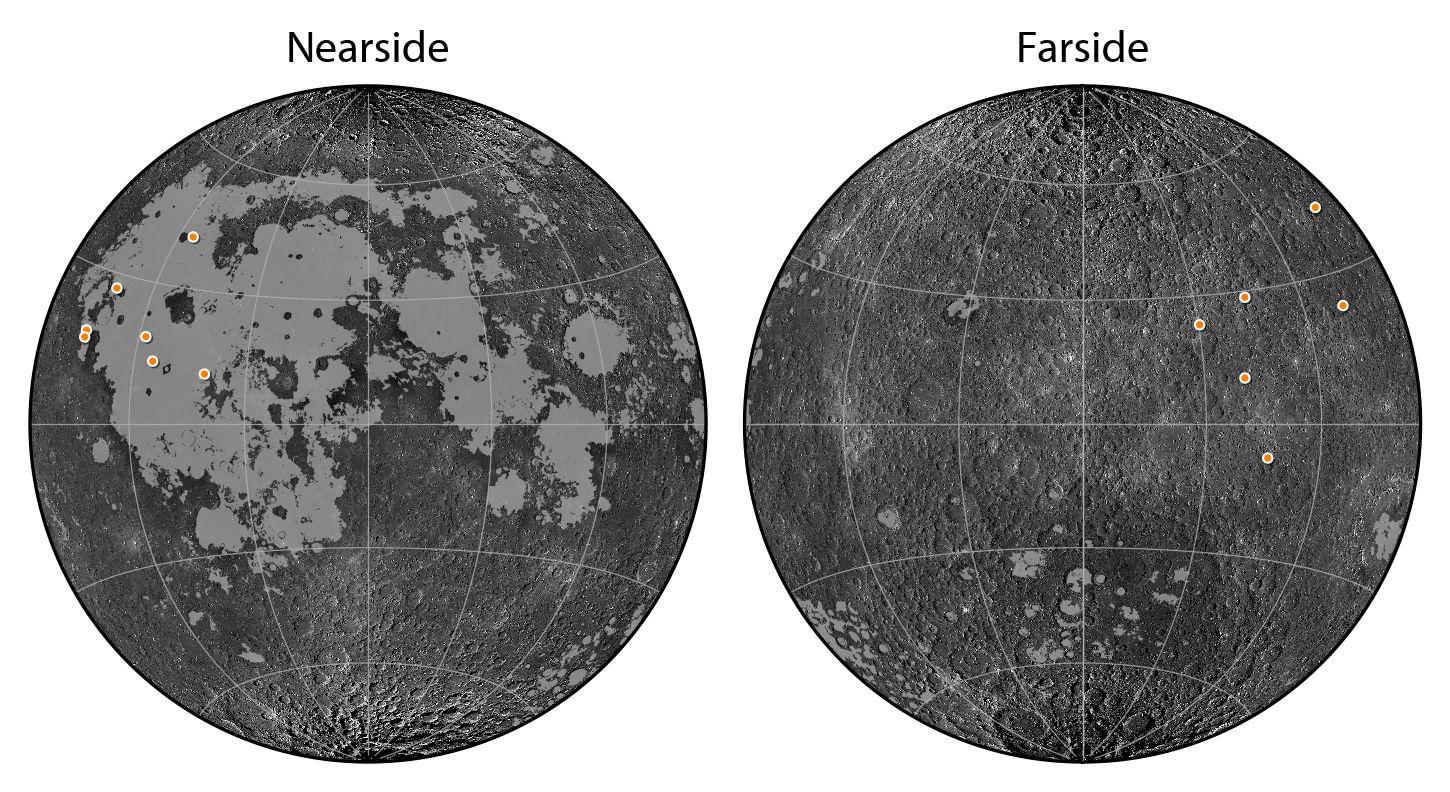

In [19]:
# Initialize axes
fig, ax, cax = generate_projected_axes(*arg_hemispheres, **kw_hemispheres)
ax[0].set_title('Nearside')
ax[1].set_title('Farside')

# Plot
with warnings.catch_warnings():
  warnings.simplefilter("ignore")  
  
  for a in ax:
    h = a.pcolormesh(*arg_wac, wac_vals, **kw_wac)
    a.gridlines(**kw_gridlines)
    # a.scatter(*arg_thiswork, **kw_thiswork)
    a.scatter(centroid_coords[1], centroid_coords[0], **kw_thiswork)
    a.spines['geo'].set_zorder(1000)
  cax.remove()
  
  # Add maria
  if SHOWMARE_THISWORKLOCATION:
    mare_ns_dissolved.plot(ax=ax[0], **kw_mare)
    mare_fs_dissolved.plot(ax=ax[1], **kw_mare)

  # Save figure
  if SAVEFIG_THISWORKLOCATION or SAVEFIG_ALL:
    plt.savefig(OUTPUT_PATH / 'Rajsic+2026-PSJ_Map_ThisWorkLocations.png', bbox_inches='tight')

  plt.show()

# Statistical analyses

## Permutation test

In [20]:
### Get global estimates
thickness_mare, clf_mare           = logistic_crossover_estimate(df_craters[df_craters['lithology'] == 'mare'], return_model=True)
thickness_highlands, clf_highlands = logistic_crossover_estimate(df_craters[df_craters['lithology'] == 'highlands'], return_model=True)
global_coeffs = {
  'mare': {
    'b0': clf_mare.intercept_[0],
    'b1': clf_mare.coef_[0][0]
  },
  'highlands': {
    'b0': clf_highlands.intercept_[0],
    'b1': clf_highlands.coef_[0][0]
  }
}
thickness_diff = abs(thickness_highlands - thickness_mare)
print(f"{'Mare':<10}: {thickness_mare:.2f} m\n{'Highlands':<10}: {thickness_highlands:.2f} m\n{'Difference':<10}: {thickness_diff:.2f} m")


Mare      : 3.96 m
Highlands : 5.80 m
Difference: 1.84 m


Actual difference: 1.84 m
Permutation mean: 0.36 m
Permutation median: 0.31 m
p-value: 0.0002 (for 9,999 permutations + actual value)


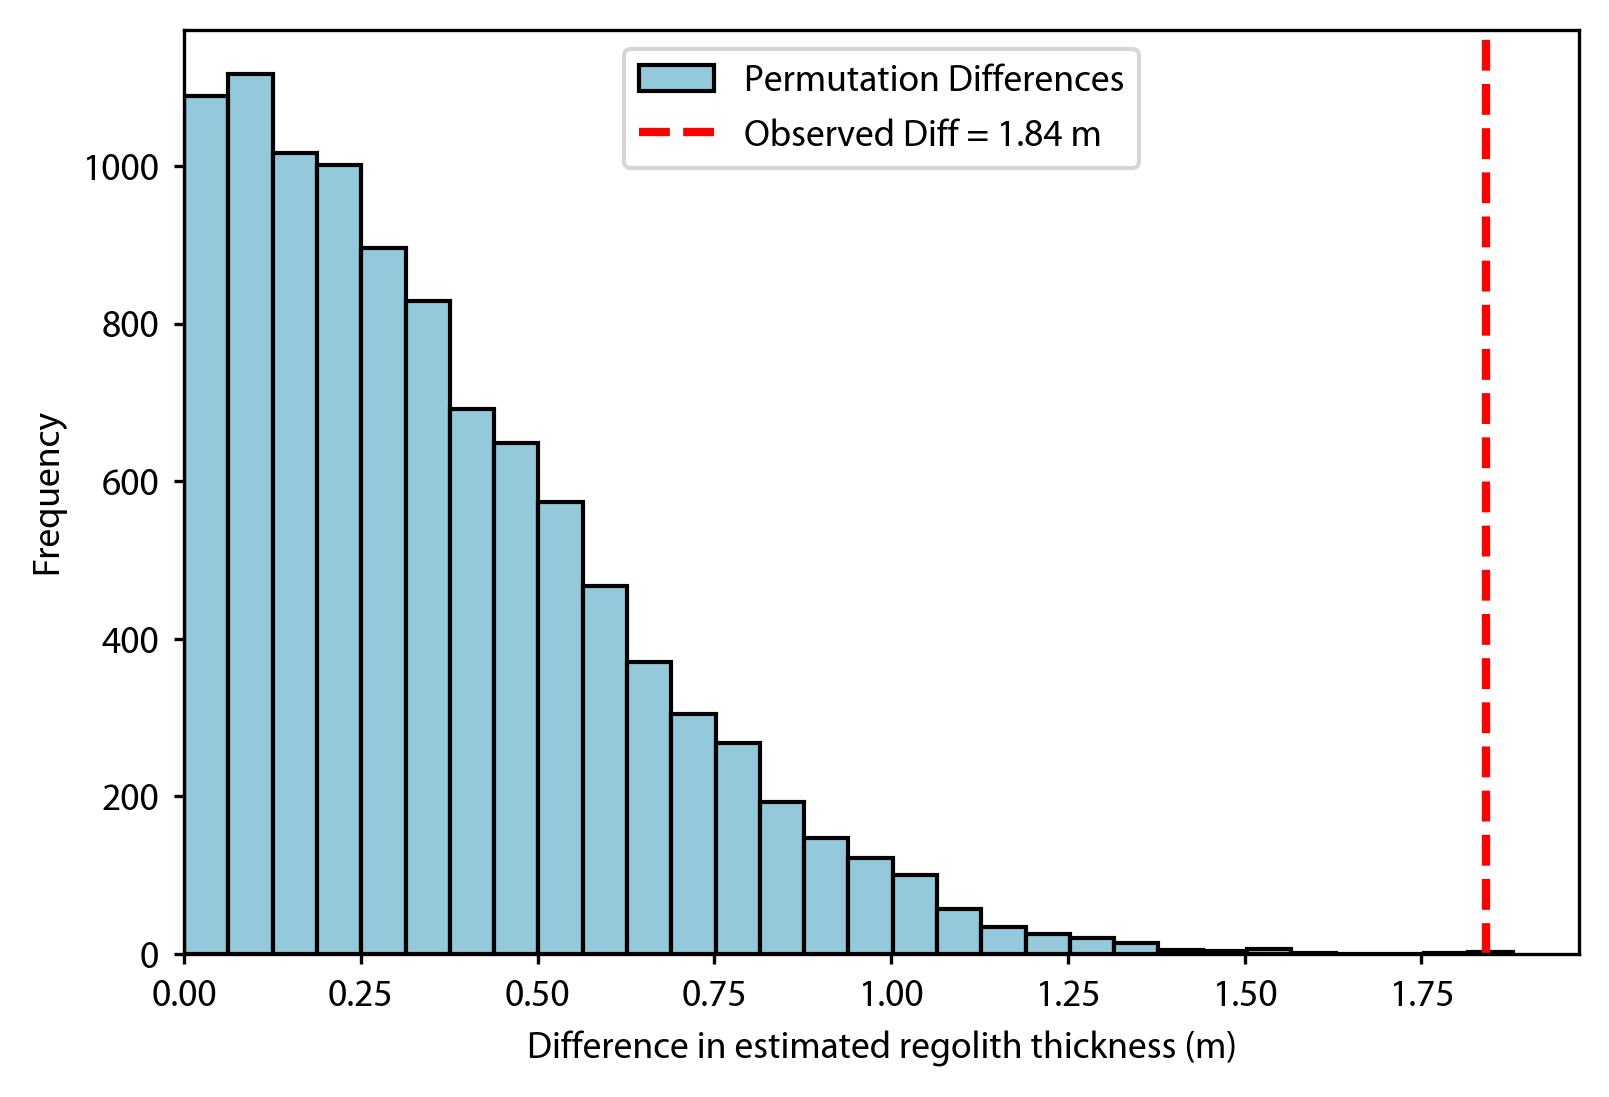

In [21]:
### Conduct permutation test
N_PERMUTATIONS = 10000
# Extract numpy arrays
X = df_craters[['exc_depth']].values
y = df_craters['is_REC'].values.astype(int)
L = df_craters['lithology'].values

# Generate array of shuffled lithology labels
rng = np.random.default_rng(0)
idx_shuffled = np.argsort(rng.random((len(L), N_PERMUTATIONS-1)), axis=0)
L_shuffled = L[idx_shuffled]

# Estimate thickness for each permutation
try:
  with open(permutation_cache, 'rb') as ff:
    permutation_diffs = pickle.load(ff)
except (FileNotFoundError, EOFError):
  if ('permutation_diffs' not in locals()) or (len(permutation_diffs) != N_PERMUTATIONS):
    df_permutation = df_craters.copy()
    permutation_diffs = [thickness_diff] #include actual value at least once to prevent p = 0.0
    for i in tqdm(range(N_PERMUTATIONS-1), desc="Permutations"):
      df_permutation['lithology'] = L_shuffled[:, i]
      permutationthickness_mare = logistic_crossover_estimate(df_permutation[df_permutation['lithology'] == 'mare'])
      permutationthickness_highlands = logistic_crossover_estimate(df_permutation[df_permutation['lithology'] == 'highlands'])
      permutation_diffs.append(abs(permutationthickness_highlands - permutationthickness_mare))
    permutation_diffs = np.asarray(permutation_diffs)
    with open(permutation_cache, 'wb') as ff:
      pickle.dump(permutation_diffs, ff)

# Calculate p-value and show results
pval = np.mean(permutation_diffs >= thickness_diff)
print(f"Actual difference: {thickness_diff:.2f} m")
print(f"Permutation mean: {np.mean(permutation_diffs):.2f} m")
print(f"Permutation median: {np.median(permutation_diffs):.2f} m")
print(f"p-value: {pval:.4g} (for {N_PERMUTATIONS-1:,d} permutations + actual value)")
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(permutation_diffs, bins=30, color=(.4, .7, .8, .7), edgecolor='black', label='Permutation Differences')
ax.axvline(thickness_diff, color='red', linestyle='dashed', linewidth=2, label=f'Observed Diff = {thickness_diff:.2f} m')
ax.set_xlabel('Difference in estimated regolith thickness (m)')
ax.set_ylabel('Frequency')
ax.set_xlim((0, None))
ax.legend()
plt.show()


## Violin plot (global)

In [22]:
### User settings
SAVEFIG_VIOLIN = False

VIOLIN_WIDTH = 0.6
COLOR_VIOLIN_NREC = "#a6cee3"#"#bcbddc"
COLOR_VIOLIN_REC  = "#fdbf6f"#"#fb9a99"
COLOR_DOT_NREC = "#1f78b4"#"#756bb1"
COLOR_DOT_REC  = "#ff7f00"#"#e31a1c"
COLOR_LOGISTIC = "#b22a20"#"#20b2aa"


highlands - b0: -4.1557, b1:  0.7165
mare      - b0: -6.2223, b1:  1.5717


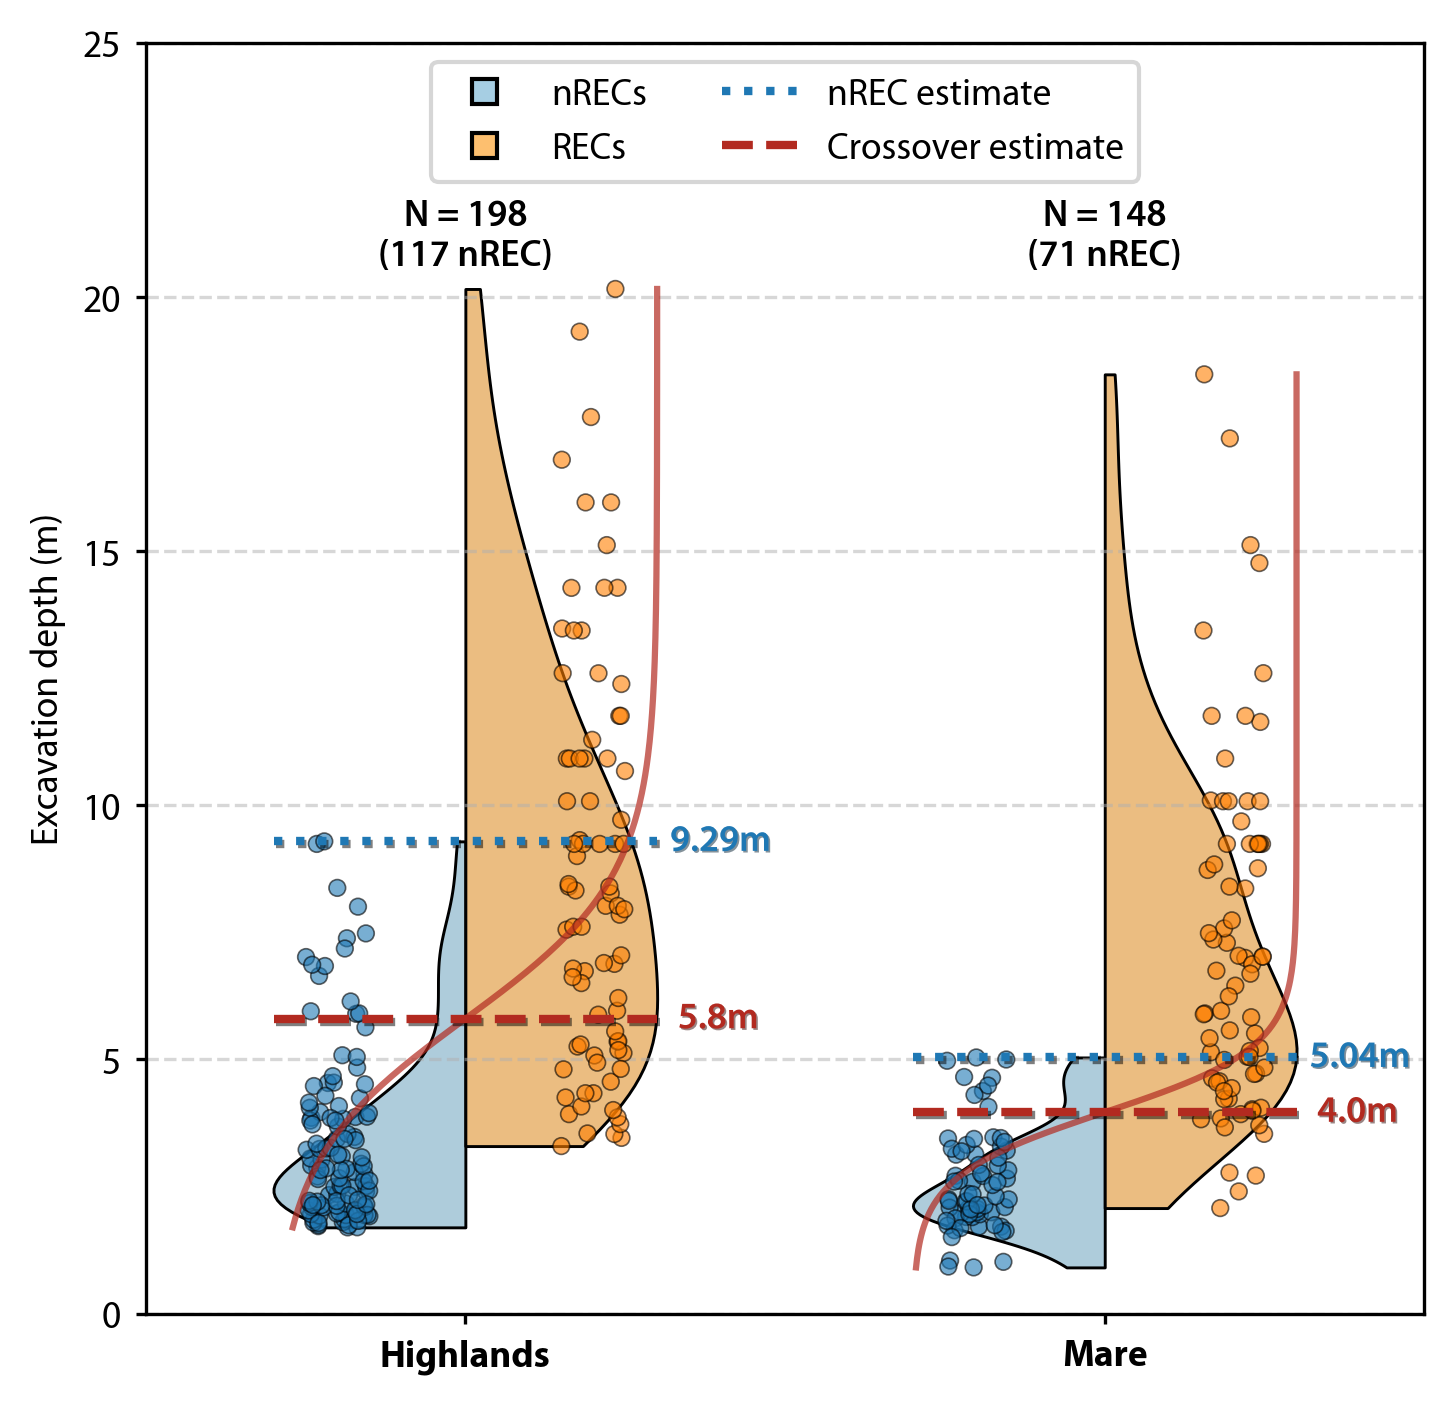

In [23]:
### Set up the output
# Data
liths = np.unique(df_craters['lithology'])
results = []
# Plot
fig, ax = plt.subplots(figsize=(5.5, 5.5))
colors_violin = [COLOR_VIOLIN_NREC, COLOR_VIOLIN_REC]
colors_dot = [COLOR_DOT_NREC, COLOR_DOT_REC]
xtick_lbls = []

### Iterate lithologies to get estimates and show results
for x, l in enumerate(liths):
  xtick_lbls.append(l.capitalize())
  ### Estimate regolith thickness
  # Filter DataFrame to this lithology
  df_subset = df_craters[df_craters['lithology'] == l]
  # Count RECs and nRECs
  N_total = len(df_subset)
  N_rec = df_subset['is_REC'].sum()
  N_nrec = N_total - N_rec
  # Get nREC-based regolith thickness estimate
  maxdepth_nrec = df_subset[~df_subset['is_REC']]['exc_depth'].max() if N_nrec > 0 else np.nan
  # Run logistic regression to get crossover estimate
  crossover, clf_log = logistic_crossover_estimate(df_subset, return_model=True)
  b0_log = clf_log.intercept_[0]
  b1_log = clf_log.coef_[0][0]
  print(f"{l:<9} - b0: {b0_log:>7.4f}, b1: {b1_log:>7.4f}")
  # print(f"{l:<12} | {f'{N_total} ({N_rec}/{N_nrec})':<15} | {maxdepth_nrec:>12.2f} | {b0_log:>14.4f} | {b1_log:>12.4f} | {crossover:>13.2f}")
  # Store results
  results.append({
    'lithology': l, 
    'Max nREC': maxdepth_nrec, 
    'Logistic': crossover
  })
  ### Plot data
  # Violin & strip plots
  sns.violinplot(
    data=df_subset, x='lithology', y='exc_depth', hue='is_REC', ax=ax, 
    split=True, inner=None, cut=0, density_norm='count', 
    palette=colors_violin, width=VIOLIN_WIDTH, 
    edgecolor=[0, 0, 0], linewidth=.7, 
    legend=False, zorder=1, 
  )
  sns.stripplot(
    data=df_subset, x='lithology', y='exc_depth', hue='is_REC', ax=ax, 
    dodge=True, jitter=True, 
    palette=colors_dot, alpha=.6, size=4, 
    edgecolor=[0, 0, 0], linewidth=.4, 
    legend=False, zorder=2,
  )
  # Logistic regression curve
  y_vals = np.linspace(df_subset['exc_depth'].min(), df_subset['exc_depth'].max(), 200)
  probs = clf_log.predict_proba(y_vals[:, None])[:, 1]
  x_vals = x + (probs - 0.5) * VIOLIN_WIDTH
  ax.plot(
    x_vals, y_vals, 
    color=COLOR_LOGISTIC, alpha=.7, 
    zorder=3, 
  )
  # Mark estimates
  xleft  = x - VIOLIN_WIDTH/2
  xright = x + VIOLIN_WIDTH/2
  ax.hlines( #nREC-based estimate
    [maxdepth_nrec, crossover], 
    xleft, xright, 
    colors = [COLOR_DOT_NREC, COLOR_LOGISTIC], 
    linewidth = 2, 
    linestyles = [':', '--'],
    alpha = 1,
    zorder=4, 
    path_effects=[patheffects.SimpleLineShadow(offset=(.7, -.7), alpha=.5), patheffects.Normal()], 
  )
  # Label estimates
  txt_fmt = {'ha': 'left', 'va': 'center', 'fontweight': 'semibold', 'zorder': 10, 'path_effects': [patheffects.SimplePatchShadow(offset=(.4, -.4), alpha=.5), patheffects.Normal()]}
  x_txt = xright + 0.02
  ax.text( #nREC-based estimate
    x_txt, maxdepth_nrec,
    f"{maxdepth_nrec:4.2f}m",
    color = COLOR_DOT_NREC,
    **txt_fmt, 
  )
  ax.text( #logistic estimate
    x_txt, crossover,
    f"{crossover:4.1f}m",
    color = COLOR_LOGISTIC,
    **txt_fmt, 
  )
  ax.text( #sample size
    x, df_craters['exc_depth'].max()+.3,
    f"N = {N_total}\n({N_nrec} nREC)",
    ha='center', va='bottom', 
    fontweight='semibold', 
    zorder=10, 
  )
### Create legend
legend_handles = [
  mlines.Line2D([], [], color=COLOR_VIOLIN_NREC, linestyle='None', marker='s', markeredgecolor=[0, 0, 0], label="nRECs"),
  mlines.Line2D([], [], color=COLOR_VIOLIN_REC, linestyle='None',  marker='s', markeredgecolor=[0, 0, 0], label="RECs"),
  mlines.Line2D([], [], color=COLOR_DOT_NREC, linestyle=':',  linewidth=2, label="nREC estimate"),
  mlines.Line2D([], [], color=COLOR_LOGISTIC, linestyle='--', linewidth=2, label="Crossover estimate"),
]
ax.legend(
  handles = legend_handles,
  ncols = 2, 
  loc = 'upper center', 
)

### Format plot
ax.grid(axis='y', linestyle='--', alpha=.5, zorder=0)
ax.set_ylabel('Excavation depth (m)')
ax.set_xlabel(None)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 25) 
ax.set_xticks(range(len(liths)), labels=xtick_lbls, weight='bold')

### Save plot
if SAVEFIG_VIOLIN or SAVEFIG_ALL:  
  plt.savefig(OUTPUT_PATH / "Rajsic+2026-PSJ_DistributionAndEstimates.png")

plt.show()

## Bootstrap (global)

In [24]:
### User settings
SAVEFIG_BOOTSTRAP = False

COLOR_HIGHLANDS = "#1f78b4"
COLOR_MARE = "#e31a1c"


### Define bootstrap functions

In [25]:
## Stratified bootstrap (maintain REC:nREC ratio for lithology)
def stratified_bootstrap_logistic_estimate(
    df: pd.DataFrame, 
    lithology: str, 
    n_bootstraps: int = 1000,
    random_seed: int = 0
) -> dict:
  """
  
  """
  # Filter to selected lithology and count total samples
  df_subset = df[df['lithology'] == lithology][['exc_depth', 'is_REC']]
  N_total = len(df_subset)
  N_rec = df_subset['is_REC'].sum()
  # Run bootstraps
  boot = {'lithology': lithology, 'estimates': []}
  seed = random_seed
  for _ in tqdm(range(n_bootstraps), desc=f"Bootstrapping {lithology}"):
    # Sample with replacement - stratified (maintain ratio of RECs to nRECs)
    seed += 1
    df_sample_rec = df_subset[df_subset['is_REC']].sample(n=N_rec, replace=True, random_state=seed)
    df_sample_nrec = df_subset[~df_subset['is_REC']].sample(n=N_total-N_rec, replace=True, random_state=seed)
    df_sample = pd.concat([df_sample_rec, df_sample_nrec])
    if (len(df_sample) != N_total) or (df_sample['is_REC'].sum() != N_rec):
      raise ValueError(f"Error in stratified sampling. N_total ({N_total:d}) or REC:nREC ratio ({N_rec:d}:{N_total-N_rec:d}) was not maintained. (N = {len(df_sample):d}, N_REC = {df_sample['is_REC'].sum():.0f})")
    # Get logistic regression estimate
    crossover = logistic_crossover_estimate(df_sample, return_model=False)
    boot['estimates'].append(crossover)
  boot['estimates'] = np.asarray(boot['estimates'])
  estimates = boot['estimates']
  boot['mean'] = estimates.mean()
  boot['median'] = np.median(estimates)
  boot['ci'] = np.percentile(estimates, [2.5, 97.5])
  return boot


In [45]:
### Plot bootstrap distributions
def plot_bootstrap(
    *bootstraps: list,
    colors: list = None,
    title: str = "",
) -> tuple:
  """
  
  """
  fig, ax = plt.subplots(figsize=(5.5, 3))
  legend_handles = []
  z = 10
  for i, boot in enumerate(bootstraps):
    clr = colors[i] if colors else None
    legend_handles.append(
      mlines.Line2D([], [], color=clr+'4c', linestyle='None', marker='s', markeredgecolor=clr, label=f"{boot['lithology'].capitalize()}")
    )
    # Plot distribution
    sns.kdeplot(
      boot['estimates'], 
      fill = True, 
      alpha = 0.3, 
      color = clr, 
      ax = ax, 
      label = boot['lithology'].capitalize(),
      zorder = z,
    )
  for i, boot in enumerate(bootstraps): # second loop so that matplotlib sets ymax based on all kdeplots
    clr = colors[i] if colors else None
    # Annotate statistics
    ci_low = boot['ci'][0]
    ci_high = boot['ci'][1]
    mean = boot['mean']
    median = boot['median']
    ax.axvline(ci_low, linestyle='--', alpha=0.8, color=clr, zorder=z)
    ax.axvline(ci_high, linestyle='--', alpha=0.8, color=clr, zorder=z)
    ax.axvline(mean, linestyle='-', color=clr, zorder=z)
    ax.axvline(median, linestyle=':', color=clr, zorder=z)
    txt_size = plt.rcParams.get('font.size')
    ax.text(
      ci_high+0.1, ax.get_ylim()[1]*0.85,
      f"Mean: {mean:.1f}m\nMedian: {median:.1f}m\n95% CI: {ci_low:.1f}m\u2013{ci_high:.1f}m",
      color = clr,
      ha = 'left', 
      va = 'center',
      fontsize = txt_size * .7,
      bbox = dict(
        facecolor = clr+'18',
        edgecolor = clr+'c0',
        boxstyle = 'round',
      ),
      path_effects = [patheffects.SimplePatchShadow(offset=(0.3, -0.3), alpha=0.3), patheffects.Normal()],
      zorder = z,
    )
  # Make legend
  legend_handles.extend([
    mlines.Line2D([], [], color='gray', linestyle='-', label='Mean'),
    mlines.Line2D([], [], color='gray', linestyle=':', label='Median'),
    mlines.Line2D([], [], color='gray', linestyle='--', label='95% CI')
  ])
  ax.legend(
    handles = legend_handles, 
  )
  # Formatting
  ax.set_title(title)
  ax.set_xlabel("Estimated regolith thickness (m)")
  ax.set_ylabel("Kernel density")
  ax.set_xlim((2, 8))
  ax.grid(alpha=.5)
  ax.minorticks_on()
  for spine in ax.spines.values():
    spine.set_zorder(z*2)
  plt.tight_layout()
  return fig, ax


### Run boostrap analyses

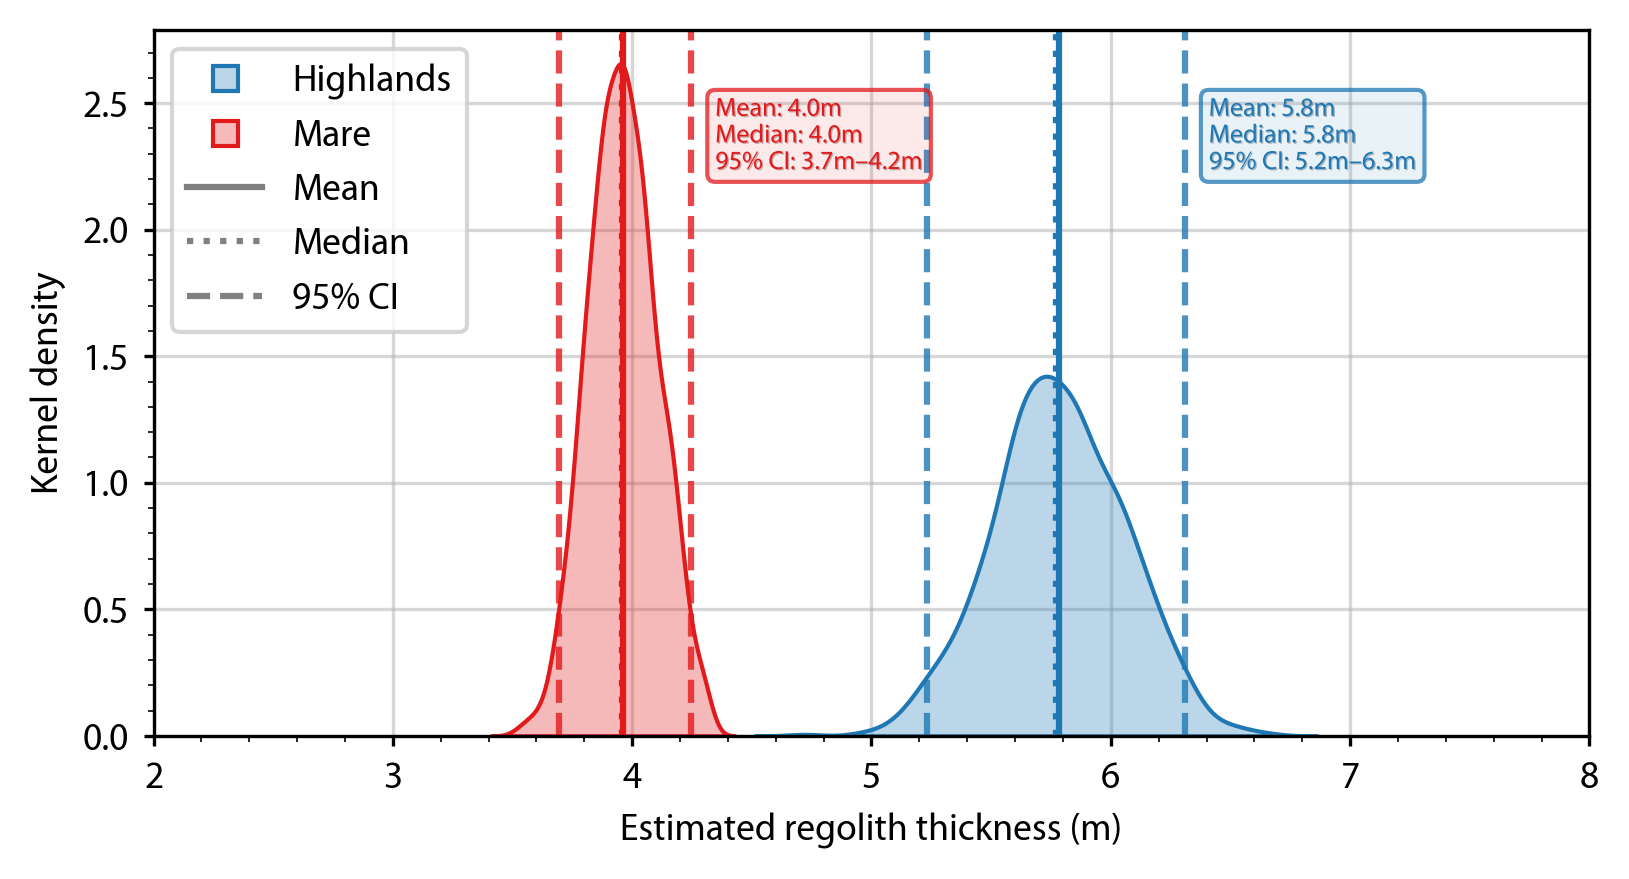

In [46]:
### Bootstrapped logistic regression estimation, stratified by REC:nREC ratio
N_BOOTSTRAPS = 1000
# Run bootstraps
try:
  with open(bootstraps_highlands_cache, 'rb') as ff:
    bootstraps_highlands_stratified = pickle.load(ff)
except (FileNotFoundError, EOFError):
  bootstraps_highlands_stratified = stratified_bootstrap_logistic_estimate(df_craters, 'highlands', N_BOOTSTRAPS)
  with open(bootstraps_highlands_cache, 'wb') as ff:
    pickle.dump(bootstraps_highlands_stratified, ff)
try:
  with open(bootstraps_mare_cache, 'rb') as ff:
    bootstraps_mare_stratified = pickle.load(ff)
except (FileNotFoundError, EOFError):
  bootstraps_mare_stratified = stratified_bootstrap_logistic_estimate(df_craters, 'mare', N_BOOTSTRAPS)
  with open(bootstraps_mare_cache, 'wb') as ff:
    pickle.dump(bootstraps_mare_stratified, ff)

# Plot distributions
fig, ax = plot_bootstrap(
  bootstraps_highlands_stratified, bootstraps_mare_stratified,
  colors = [COLOR_HIGHLANDS, COLOR_MARE]
)

if SAVEFIG_BOOTSTRAP or SAVEFIG_ALL:
  plt.savefig(OUTPUT_PATH / "Rajsic+2026_BootstrapStratified.png")

plt.show()


## Rarefaction curve (global)

### Define rarefaction functions

In [28]:
### Define rarefaction function
def rarefaction_logistic_estimate(
    df: pd.DataFrame, 
    lithology: str, 
    samplings_per_k: int = 200,
    k_step: int = 5,
    random_seed: int = 0,
) -> dict:
  """
  
  """
  # Extract the lithology of interest
  df_subset = df[df['lithology'] == lithology][['exc_depth', 'is_REC']]
  N_total = len(df_subset)
  # Prepare the rarefaction
  k_vals = list(range(2, N_total, k_step)) #generate the k steps (logistic regression requires ≥2 points)
  N_iterations = len(k_vals) * samplings_per_k
  rng = np.random.default_rng(random_seed)
  idx_shuffled = np.argsort(rng.random((N_total, N_iterations)), axis=0)
  rarefaction = {'lithology': lithology, 'k_vals': k_vals, 'means': [], 'stds': [], 'fail_rate': []}
  idx = 0
  for k in tqdm(k_vals, desc=f"Rarefaction for {lithology}"):
    results = []
    for _ in range(samplings_per_k):
      df_sample = df_subset.iloc[idx_shuffled[:k, idx]]
      if 0 < df_sample['is_REC'].sum() < len(df_sample): #need at least one REC and one nREC for logistic regression to work
        crossover = logistic_crossover_estimate(df_sample, return_model=False)
      else:
        crossover = np.nan
      idx += 1
      results.append(crossover)
    results = np.asarray(results)
    rarefaction['means'].append(np.nanmean(results))
    rarefaction['stds'].append(np.nanstd(results))
    rarefaction['fail_rate'].append(np.sum(np.isnan(results)) / samplings_per_k)
  # Append the results for k = N_total
  rarefaction['k_vals'] = np.append(rarefaction['k_vals'], N_total) 
  rarefaction['means'].append(logistic_crossover_estimate(df_subset, return_model=False))
  rarefaction['stds'].append(0)
  rarefaction['fail_rate'].append(0)
  # Convert to ndarrays
  rarefaction['means'] = np.asarray(rarefaction['means'])
  rarefaction['stds'] = np.asarray(rarefaction['stds'])
  rarefaction['fail_rate'] = np.asarray(rarefaction['fail_rate'])
  return rarefaction


In [29]:
### Define rarefaction plotting function
def plot_rarefaction(
    *rarefactions: list,
    colors: list = None,
    title: str = "",
) -> tuple:
  """
  
  """
  fig, ax = plt.subplots(figsize=(5.5, 3))
  legend_handles = []
  z = 10
  for i, rarefaction in enumerate(rarefactions):
    clr = colors[i] if colors else None
    legend_handles.append(
      mlines.Line2D([], [], color=clr, label=f"{rarefaction['lithology'].capitalize()}")
    )
    # Plot mean estimate with shaded std dev
    k_vals = rarefaction['k_vals']
    means = rarefaction['means']
    stds = rarefaction['stds']
    ax.plot(k_vals, means, color=clr, zorder=z)
    ax.fill_between(
      k_vals, 
      np.array(means) - np.array(stds), 
      np.array(means) + np.array(stds), 
      color = clr+'4c', 
      edgecolor = clr,
      linewidth = 0.7,
      zorder = z - 1
    )

  # Make legend
  legend_handles.extend([
    mlines.Line2D([], [], color='gray', linestyle='-', label="Mean"),
    mlines.Line2D([], [], color='#8888884c', linestyle='None', marker='s', markeredgecolor='#888888', markeredgewidth=0.7, label="1\u03c3 range"),
  ])
  ax.legend(
    handles = legend_handles, 
  )

  # Formatting
  ax.set_title(title)
  ax.set_xlabel("Sample size (k)")
  ax.set_ylabel("Estimated regolith thickness (m)")
  ax.set_xlim((0, None))
  if ax.get_ylim()[0] < 0:
    ax.set_ylim((0, ax.get_ylim()[1]))
  ax.grid(axis='x', alpha=.5)
  ax.minorticks_on()
  ax.grid(which='minor', axis='x', alpha=.2)
  for spine in ax.spines.values():
    spine.set_zorder(z*2)
  plt.show()
  return fig, ax


### Run rarefaction analyses

In [30]:
### User settings
SAVEFIG_RAREFACTION = False


Success thresholds
-------------------
No failures at k ≥ threshold:
Highlands: k = 11
Mare:      k =  9

Std. dev. ≤ 0.92m:
Highlands: k = 27
Mare:      k =  9


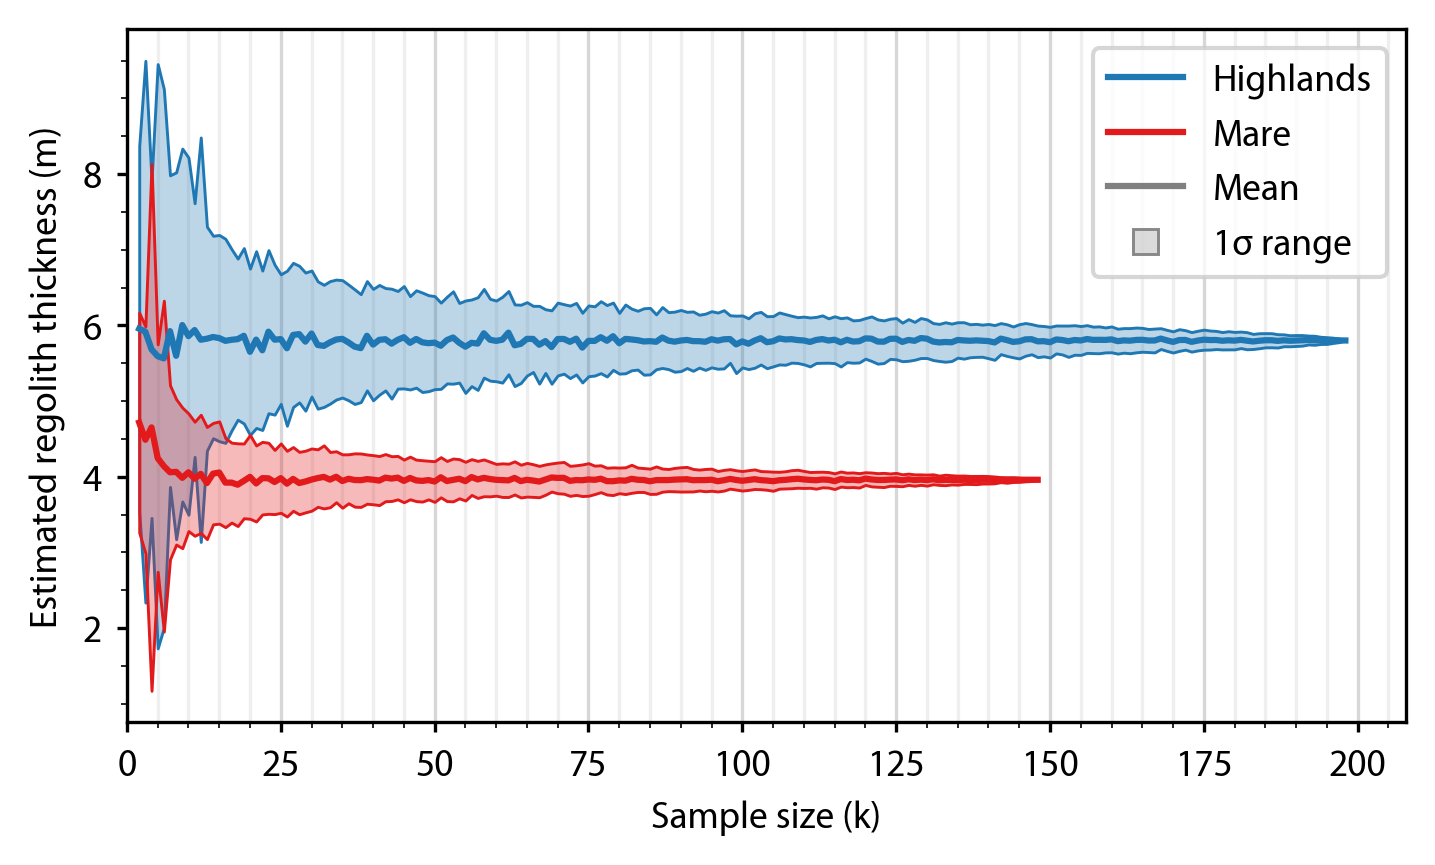

In [44]:
### Rarefaction analyses
SAMPLINGS_PER_K = 200
K_STEP = 1
# Run rarefaction
try:
  with open(rarefaction_highlands_cache, 'rb') as ff:
    rarefaction_highlands = pickle.load(ff)
except (FileNotFoundError, EOFError):
  rarefaction_highlands = rarefaction_logistic_estimate(df_craters, 'highlands', samplings_per_k=SAMPLINGS_PER_K, k_step=K_STEP)
  with open(rarefaction_highlands_cache, 'wb') as ff:
    pickle.dump(rarefaction_highlands, ff)
try:
  with open(rarefaction_mare_cache, 'rb') as ff:
    rarefaction_mare = pickle.load(ff)
except (FileNotFoundError, EOFError):
  rarefaction_mare = rarefaction_logistic_estimate(df_craters, 'mare', samplings_per_k=SAMPLINGS_PER_K, k_step=K_STEP)
  with open(rarefaction_mare_cache, 'wb') as ff:
    pickle.dump(rarefaction_mare, ff)

# Print fail rates
def _get_success_threshold(rarefaction, condition_array):
  idx_nofails = np.flatnonzero(~condition_array)[-1]
  return rarefaction['k_vals'][idx_nofails]
idx_nofails_highlands = np.flatnonzero(rarefaction_highlands['fail_rate'])[-1] + 1
nofails_highlands = rarefaction_highlands['k_vals'][idx_nofails_highlands]
idx_nofails_mare = np.flatnonzero(rarefaction_mare['fail_rate'])[-1] + 1
nofails_mare = rarefaction_mare['k_vals'][idx_nofails_mare]
print(f"Success thresholds\n{'-'*19}")
print("No failures at k ≥ threshold:")
print(f"Highlands: k = {_get_success_threshold(rarefaction_highlands, rarefaction_highlands['fail_rate']==0):>2d}")
print(f"Mare:      k = {_get_success_threshold(rarefaction_mare, rarefaction_mare['fail_rate']==0):>2d}")
success_thick = thickness_diff / 2
print(f"\nStd. dev. ≤ {success_thick:.2g}m:")
print(f"Highlands: k = {_get_success_threshold(rarefaction_highlands, rarefaction_highlands['stds'] <= success_thick):>2d}")
print(f"Mare:      k = {_get_success_threshold(rarefaction_mare, rarefaction_mare['stds'] <= success_thick):>2d}")


# Plot results
fig, ax = plot_rarefaction(
  rarefaction_highlands, rarefaction_mare, 
  colors = [COLOR_HIGHLANDS, COLOR_MARE],
)

if SAVEFIG_RAREFACTION:
  plt.savefig(OUTPUT_PATH / "Rajsic+2026_LogisticRegressionRarefaction.png")


# Estimate and plot global thickness

## Estimate regolith thickness for this work's points

In [32]:
### User settings
K_MIN = 25 #number of craters above which highlands and mare estimates are reliably distinct (based on rarefaction analysis)


In [33]:
### Calculate unpooled logistic crossover estimate for each geographic group
group_estimates = {}
for g in groups:
  df_subset = df_craters[df_craters['group'] == g]
  lithology = df_subset['lithology'].values[0]
  crossover, clf = logistic_crossover_estimate(df_subset, return_model=True)
  group_estimates[g] = {
    'lithology': df_subset['lithology'].values[0], 
    'crossover': crossover, 
    'b0': clf.intercept_[0], 
    'b1': clf.coef_[0][0],
  }
  print(f"Group {g:>2d} ({lithology:<9}): Crossover estimate = {crossover:.2f} m (N={len(df_subset)})")

### Compute between-group statistics (per lithology)
b0_mare_var = np.var([est['b0'] for est in group_estimates.values() if est['lithology'] == 'mare'])
b1_mare_var = np.var([est['b1'] for est in group_estimates.values() if est['lithology'] == 'mare'])
b0_highlands_var = np.var([est['b0'] for est in group_estimates.values() if est['lithology'] == 'highlands'])
b1_highlands_var = np.var([est['b1'] for est in group_estimates.values() if est['lithology'] == 'highlands'])


Group  1 (mare     ): Crossover estimate = 5.02 m (N=28)
Group  2 (mare     ): Crossover estimate = 4.05 m (N=19)
Group  3 (mare     ): Crossover estimate = 2.93 m (N=23)
Group  4 (mare     ): Crossover estimate = 3.32 m (N=10)
Group  5 (mare     ): Crossover estimate = 5.08 m (N=34)
Group  6 (mare     ): Crossover estimate = 3.22 m (N=34)
Group  7 (highlands): Crossover estimate = 7.38 m (N=37)
Group  8 (highlands): Crossover estimate = 4.65 m (N=23)
Group  9 (highlands): Crossover estimate = 4.60 m (N=34)
Group 10 (highlands): Crossover estimate = 7.91 m (N=34)
Group 11 (highlands): Crossover estimate = 4.25 m (N=13)
Group 12 (highlands): Crossover estimate = 3.16 m (N=12)
Group 13 (highlands): Crossover estimate = 4.65 m (N=45)


In [34]:
### Weighted estimate of thickness at each of this work's points
pooled_data = []
for group_id, n_local in zip(groups, counts):
  # Fetch global and local crossover estimates
  lithology = group_estimates[group_id]['lithology']
  global_crossover = thickness_mare if (lithology == 'mare') else thickness_highlands
  local_crossover = group_estimates[group_id]['crossover']
  # Compute weighted mean for local crossover
  W = n_local / (n_local + K_MIN)
  pooled_crossover = (W * local_crossover) + ((1 - W) * global_crossover)
  # Export results for later conversion to DataFrame
  lat, lon = centroids[group_id]
  pooled_data.append({
    'lat': lat,
    'lon': lon,
    'regolith_thickness (m)': pooled_crossover,
    'Source': 'this work',
    'Method': f"N_local-weighted mean ({lithology})"
  })
  print(f"Group {group_id:>2d} ({lithology:<9}): n={n_local:>2d}, W={W:.2f}, Thickness={pooled_crossover:.2f}m")

### Convert to DataFrame
df_pooled = pd.DataFrame(pooled_data)
df_pooled


Group  1 (mare     ): n=28, W=0.53, Thickness=4.52m
Group  2 (mare     ): n=19, W=0.43, Thickness=4.00m
Group  3 (mare     ): n=23, W=0.48, Thickness=3.47m
Group  4 (mare     ): n=10, W=0.29, Thickness=3.78m
Group  5 (mare     ): n=34, W=0.58, Thickness=4.61m
Group  6 (mare     ): n=34, W=0.58, Thickness=3.53m
Group  7 (highlands): n=37, W=0.60, Thickness=6.75m
Group  8 (highlands): n=23, W=0.48, Thickness=5.25m
Group  9 (highlands): n=34, W=0.58, Thickness=5.11m
Group 10 (highlands): n=34, W=0.58, Thickness=7.02m
Group 11 (highlands): n=13, W=0.34, Thickness=5.27m
Group 12 (highlands): n=12, W=0.32, Thickness=4.94m
Group 13 (highlands): n=45, W=0.64, Thickness=5.06m


,lat,lon,regolith_thickness (m),Source,Method
0,27.111220,-71.214867,4.521834,this work,N_local-weighted mean (mare)
1,11.244084,-40.676062,3.997960,this work,N_local-weighted mean (mare)
2,18.442517,-58.089406,3.466899,this work,N_local-weighted mean (mare)
3,13.419242,-54.883216,3.777655,this work,N_local-weighted mean (mare)
4,17.941186,-76.061500,4.606600,this work,N_local-weighted mean (mare)
5,41.354966,-55.378698,3.533305,this work,N_local-weighted mean (mare)
6,42.574076,-99.031315,6.745197,this work,N_local-weighted mean (highlands)
7,23.140423,-149.706098,5.248255,this work,N_local-weighted mean (highlands)
8,-7.527028,-134.086720,5.108240,this work,N_local-weighted mean (highlands)
9,23.375056,-108.009476,7.016597,this work,N_local-weighted mean (highlands)


In [35]:
### Add this work's estimates to the data
df_combined = pd.concat([df_regolith, df_pooled], ignore_index=True)
df_combined.to_excel(OUTPUT_PATH / "Rajsic+2026_Table_SM3.xlsx", index=False)
df_combined


,lat,lon,regolith_thickness (m),Source,Method
0,34.733275,-14.923168,6.500000,Yu+2025;Yan+2025;Zhang+2025,Change'3: Lunar Penetrating Radar
1,-44.400000,176.200000,12.500000,Yu+2025;Yan+2025;Zhang+2025,Change'4: Lunar Penetrating Radar
2,40.763881,-58.385738,5.000000,Yu+2025;Yan+2025;Zhang+2025,Change'5: Lunar Regolith Penetrating Radar
3,-37.063191,-153.720000,6.000000,Yu+2025;Yan+2025;Zhang+2025,"Change'6: in situ data from imagery, spectral ..."
4,0.680746,23.466554,4.400000,Apollo 11,Passive seismic
...,...,...,...,...,...
62,-7.527028,-134.086720,5.108240,this work,N_local-weighted mean (highlands)
63,23.375056,-108.009476,7.016597,this work,N_local-weighted mean (highlands)
64,16.583773,-76.045511,5.268340,this work,N_local-weighted mean (highlands)
65,28.564781,-135.758478,4.942530,this work,N_local-weighted mean (highlands)


## IDW interpolation of all data

In [36]:
### Prepare the map grid
pts = generate_gridpoints(nlat=20)
ctr_lon, ctr_lat = pts['ctr']['lon'], pts['ctr']['lat']
# Prepare the estimation RTree
tree = build_tree(
  df_combined['lon'],
  df_combined['lat'],
  df_combined['regolith_thickness (m)']
)


In [37]:
### IDW estimation of grid values
idw_vals, _ = tree.inverse_distance_weighting(
  coordinates = np.column_stack((ctr_lon.ravel(), ctr_lat.ravel())),
  k = 9, p = 2, within = False
)
idw_vals = idw_vals.reshape(ctr_lon.shape)


## Plot IDW estimation map

In [38]:
### User settings
SAVEFIG_IDWMAP = False
SHOWMARE_IDWMAP = True
DEBUG_IDWMAP = False

PERCENTILES_IDWMAP = [5, 25, 50, 75, 95]


In [39]:
### Additional plot formatting
### Measured thickness
# Positional args
arg_scatter = [
  df_combined['lon'],
  df_combined['lat']
]
# Keywords
kw_scatter = {
  's': 5,
  'c': df_combined['regolith_thickness (m)'],
  'vmin': kw_regolith.get('vmin'),
  'vmax': kw_regolith.get('vmax'),
  'linewidths': .5,
  'edgecolors': [1, 1, 1, 1],
  'transform': PLATE_CARREE,
  'zorder': 100,
}
# Define and add dropshadow effect
shadow_offset = kw_scatter.get('linewidths', 0) * 0.8
line_shadow = [
  patheffects.SimpleLineShadow(
    offset = (shadow_offset, -shadow_offset), 
    alpha = .5
  ),
  patheffects.Normal()
]
kw_scatter.update({'path_effects': line_shadow})

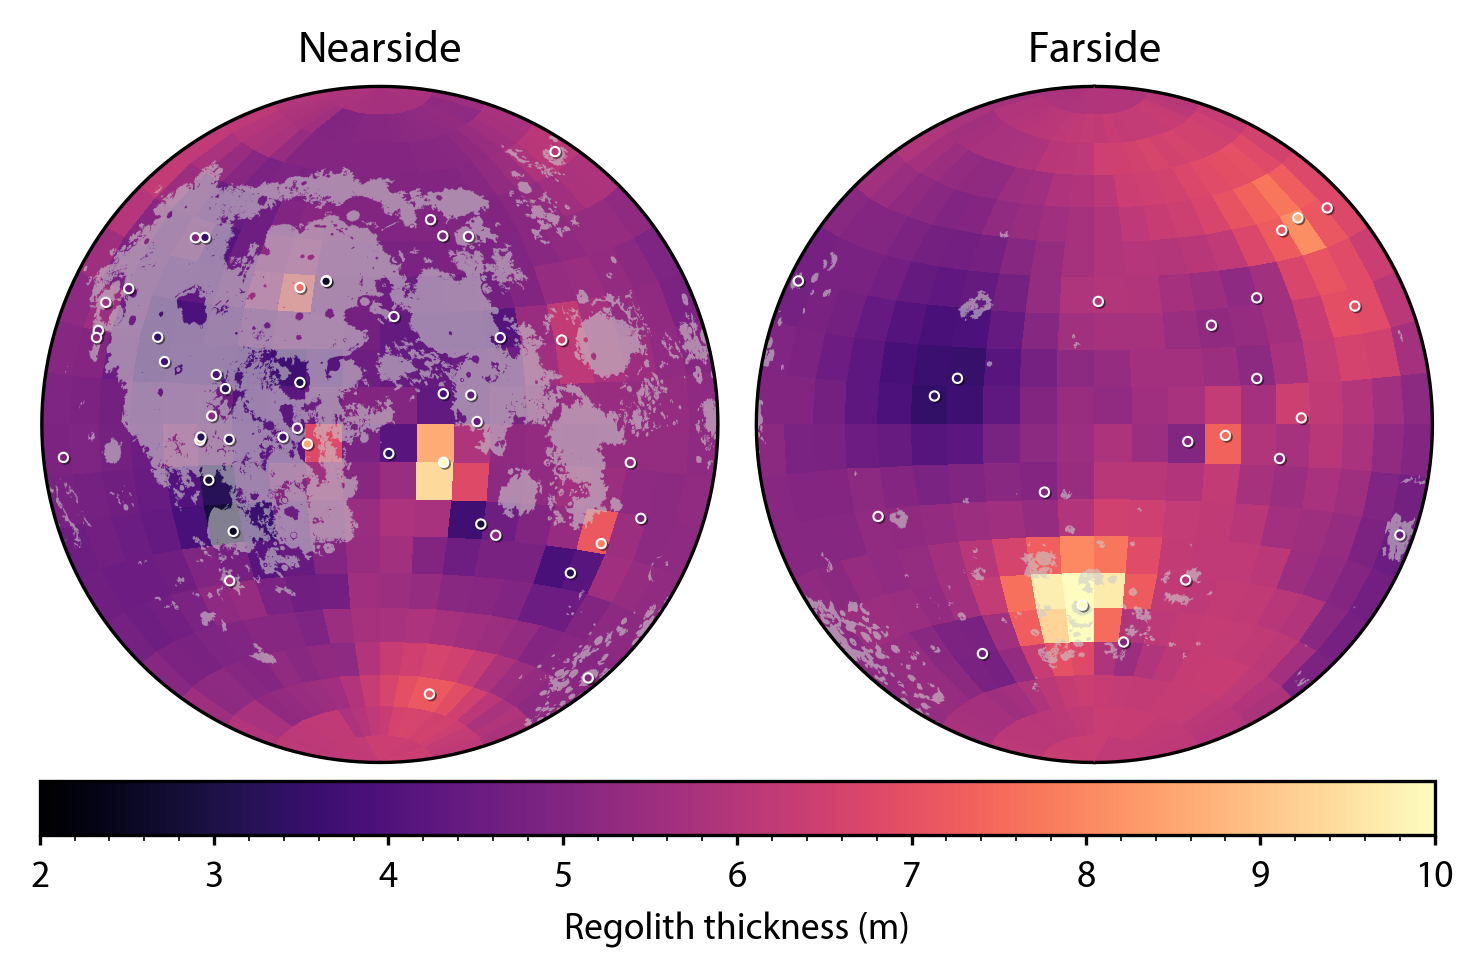

In [40]:
with warnings.catch_warnings():
  warnings.simplefilter("ignore")
  
  # Initialize axes
  fig, ax, cax = generate_projected_axes(*arg_hemispheres, **kw_hemispheres)
  ax[0].set_title('Nearside')
  ax[1].set_title('Farside')

  # Plot
  for a in ax:
    h = a.pcolormesh(pts['edge']['lon'], pts['edge']['lat'], idw_vals, **kw_regolith)
    # a.gridlines(**kw_gridlines)
    a.scatter(*arg_scatter, **kw_scatter)
    a.spines['geo'].set_zorder(1000)
    
    # Check that pcolormesh values match actual values plotted as points
    if DEBUG_IDWMAP:
      a.scatter(ctr_lon, ctr_lat, c=idw_vals, s=1, ec=[0, 0, 0, 1], lw=.03, vmin=kw_regolith.get('vmin'), vmax=kw_regolith.get('vmax'), transform=PLATE_CARREE)
  plt.colorbar(h, cax=cax, **kw_cbar)
  cax.minorticks_on()
  
  # Add maria
  if SHOWMARE_IDWMAP:
    mare_ns_dissolved.plot(ax=ax[0], **kw_mare)
    mare_fs_dissolved.plot(ax=ax[1], **kw_mare)
  
  # Save figure
  if SAVEFIG_IDWMAP or SAVEFIG_ALL:
    ttl = "Rajsic+2026-PSJ_Map_IDWmap"
    ext = ".png"
    if SHOWMARE_IDWMAP:
      detail = "_WithMare"
    else:
      detail = "_NoMare"
    if DEBUG_IDWMAP:
      detail += "_ValueCheck"
    plt.savefig(OUTPUT_PATH / Path(ttl+detail+ext), bbox_inches='tight')
  
  plt.show()


In [41]:
### Get mare vs. highlands statistics
# Define a mare mask for the IDW grid
gdf_IDW = gpd.GeoDataFrame(
  geometry=gpd.points_from_xy(ctr_lon.ravel(), ctr_lat.ravel()),
  crs=PLATE_CARREE,
).to_crs(mare_dissolved.crs)
mare_geom = mare_dissolved.geometry.iloc[0]
mare_mask_IDW = gdf_IDW.intersects(mare_geom).to_numpy().reshape(ctr_lon.shape)
# Mask the IDW values and compute statistics
w_lat = np.cos(np.radians(ctr_lat))
idw_vals_mare = np.where(mare_mask_IDW, idw_vals, np.nan)
idw_mean_mare = np.average(idw_vals_mare[mare_mask_IDW], weights=w_lat[mare_mask_IDW])
idw_pcts_mare = np.percentile(idw_vals_mare[mare_mask_IDW], q=PERCENTILES_IDWMAP, weights=w_lat[mare_mask_IDW], method='inverted_cdf')
idw_vals_highlands = np.where(~mare_mask_IDW, idw_vals, np.nan)
idw_mean_highlands = np.average(idw_vals_highlands[~mare_mask_IDW], weights=w_lat[~mare_mask_IDW])
idw_pcts_highlands = np.percentile(idw_vals_highlands[~mare_mask_IDW], q=PERCENTILES_IDWMAP, weights=w_lat[~mare_mask_IDW], method='inverted_cdf')
# Print statistics
print("Latitude-weighted statistics for IDW estimates:")
print(f"Mare      - mean: {idw_mean_mare:.1f}m   percentiles {PERCENTILES_IDWMAP}: {idw_pcts_mare.round(1)}")
print(f"Highlands - mean: {idw_mean_highlands:.1f}m   percentiles {PERCENTILES_IDWMAP}: {idw_pcts_highlands.round(1)}")


Latitude-weighted statistics for IDW estimates:
Mare      - mean: 4.8m   percentiles [5, 25, 50, 75, 95]: [3.8 4.4 4.7 5.1 5.8]
Highlands - mean: 5.5m   percentiles [5, 25, 50, 75, 95]: [4.2 5.  5.4 5.9 6.9]
